In [30]:
import sys
import numpy as np
import anndata as ad
import polars as pl
import pickle

import src as scit

In [31]:
cttag = ad.read_h5ad('private/data/clean_method/cttag_wt_inferred.h5ad')

In [32]:
active_meth = pl.read_csv('private/data/meth_active.csv', has_header=False)['column_1'].to_numpy()

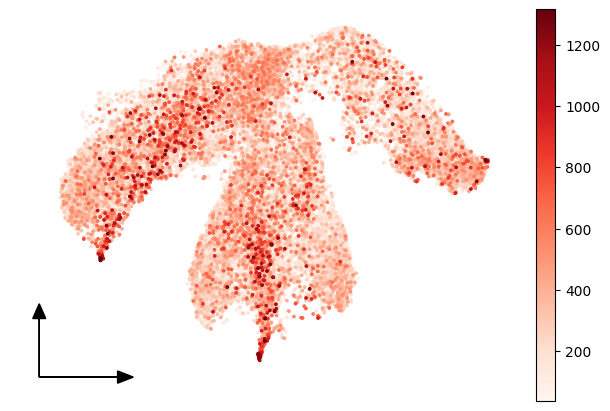

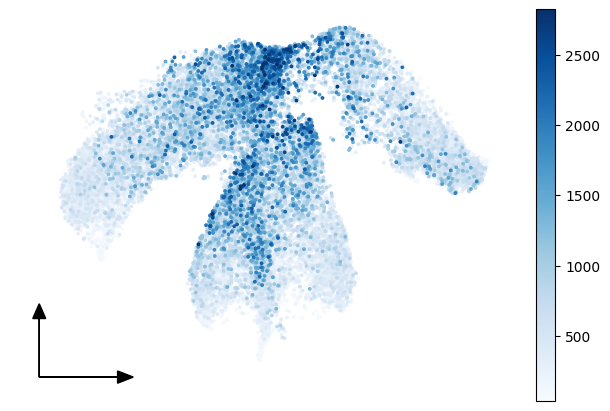

In [33]:
scit.set_defaults(figsize=(6,4))
scit.pl.embedding2d(cttag, 'X_umap', 'meth_total_counts', cmap='Reds')
scit.pl.embedding2d(cttag, 'X_umap', 'acet_total_counts', cmap='Blues')

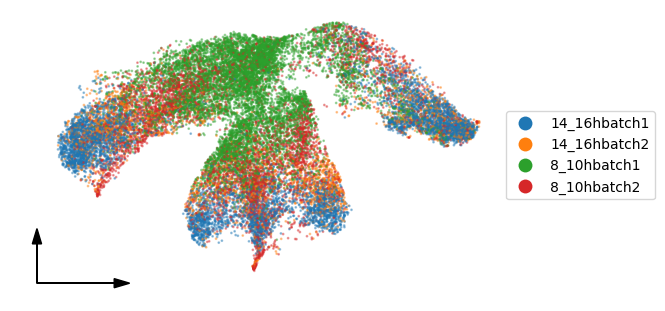

In [34]:
import pandas as pd
scit.set_defaults(figsize=(5,3))
cttag.obs['time_batch'] = pd.Categorical(cttag.obs['timep'].to_numpy() + cttag.obs['batch'].to_numpy())
scit.pl.embedding2d(cttag, 'X_umap', 'time_batch', size=1, alpha=0.4)

In [35]:
lc_acet = scit.tl.make_layer_config(
    "acet",
    in_obsm=True,
    #log_transform=True,
    #normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
lc_meth = scit.tl.make_layer_config(
    "meth",
    in_obsm=True,
    #log_transform=True,
    #normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)

In [36]:
acet_marker = pl.read_csv('private/data/acet_label_vs_rest.csv')
meth_marker = pl.read_csv('private/data/meth_label_vs_rest.csv')

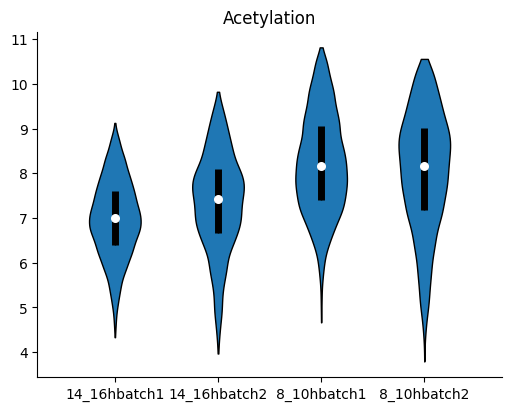

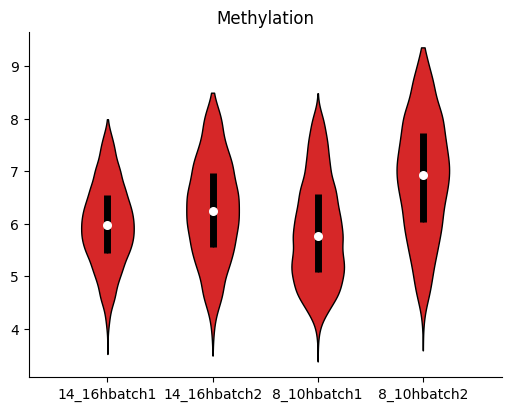

In [49]:
scit.set_defaults(figsize=(5,4))
ddict = scit.tl.membership_summary(cttag, lc_acet, 'time_batch', use_cached_mask=False)
scit.pl.int.violin([np.log2(d.sum(axis=1).A1) for d in ddict.values()], ddict.keys(), color='tab:blue', title="Acetylation")

ddict = scit.tl.membership_summary(cttag, lc_meth, 'time_batch', use_cached_mask=False)
scit.pl.int.violin([np.log2(d.sum(axis=1).A1) for d in ddict.values()], ddict.keys(), color='tab:red', title="Methylation")

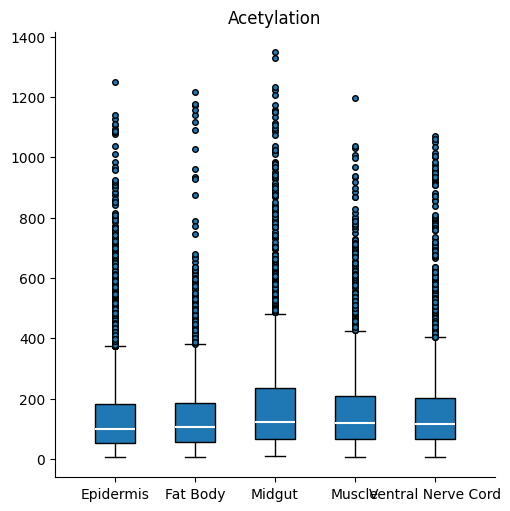

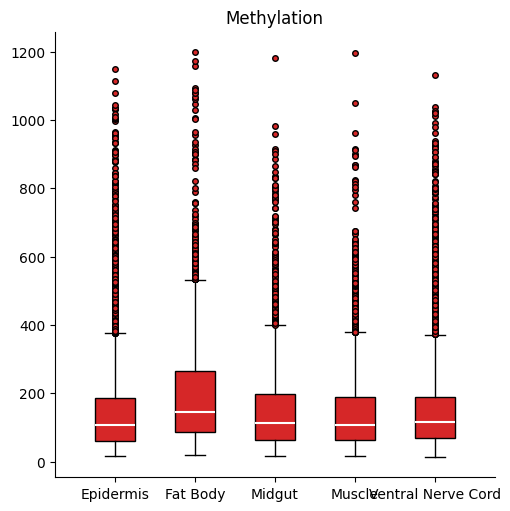

In [8]:
scit.set_defaults(figsize=(5,5))
ddict = scit.tl.membership_summary(cttag, lc_acet, 'label', use_cached_mask=False, normalize_per_class_obs_key='time_batch')
scit.pl.int.boxplot([(d.sum(axis=1).A1) for d in ddict.values()], ddict.keys(), color='tab:blue', title="Acetylation")

ddict = scit.tl.membership_summary(cttag, lc_meth, 'label', use_cached_mask=False, normalize_per_class_obs_key='time_batch')
scit.pl.int.boxplot([(d.sum(axis=1).A1) for d in ddict.values()], ddict.keys(), color='tab:red', title="Methylation")

In [37]:
lc_acet = scit.tl.make_layer_config(
    "acet",
    in_obsm=True,
    #log_transform=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
lc_meth = scit.tl.make_layer_config(
    "meth",
    in_obsm=True,
    #log_transform=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)

In [38]:
scit.tl.layer_pick_features(cttag, lc_acet, active_meth)
df_acet = scit.adv.shannon_entropy(cttag, lc_acet, 'timep', 'label')

scit.tl.layer_pick_features(cttag, lc_meth, active_meth)
df_meth = scit.adv.shannon_entropy(cttag, lc_meth, 'timep', 'label')
df_meth

name,entropy_14_16h,prev_14_16h,entropy_8_10h,prev_8_10h
str,f64,f32,f64,f32
"""CG8043""",2.15942,2.128684,2.19794,2.41678
"""CG14329""",2.125911,3.122571,2.030801,2.533556
"""scaRNA:MeU2-C41""",2.222764,2.605984,2.275667,2.957579
"""lncRNA:CR45901""",2.31382,8.487317,2.308295,7.717779
"""Taf12""",2.189719,0.905046,2.283007,0.886085
…,…,…,…,…
"""fd102C""",2.312995,4.880191,2.302016,5.132072
"""toy""",2.306943,9.247663,2.300753,9.067918
"""lncRNA:CR44024""",2.268176,3.896526,2.293211,4.778286


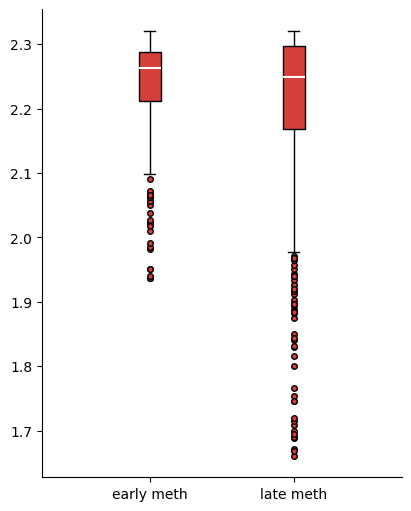

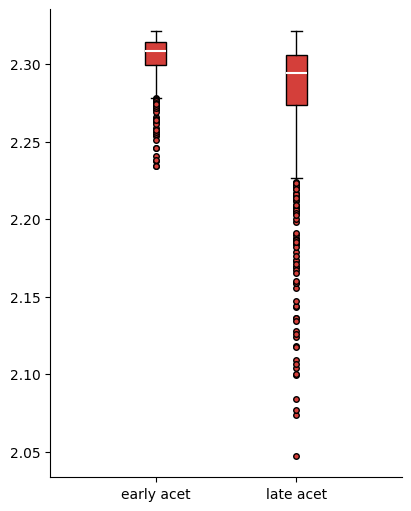

In [17]:
scit.set_defaults(figsize=(4,5))
scit.pl.int.boxplot(
    [df_meth['entropy_8_10h'],  df_meth['entropy_14_16h']], 
    ['early meth', 'late meth'],
    show=True
)#.savefig('private/newest/figures/entropy_all.pdf')

scit.pl.int.boxplot(
    [df_acet['entropy_8_10h'],  df_acet['entropy_14_16h']], 
    ['early acet', 'late acet'],
    show=True
)#.savefig('private/newest/figures/entropy_all.pdf')

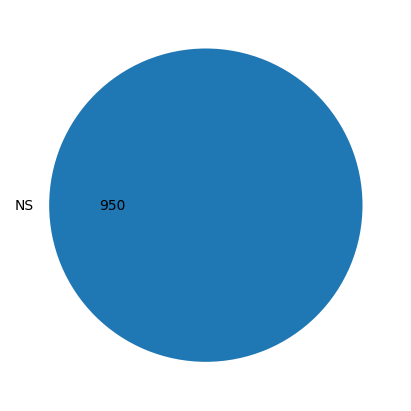

In [12]:
#th_e_early, th_e_late, th_p_early, th_p_late = (1, 1, 0.1, 0.1)
th_e_early, th_e_late, th_p_early, th_p_late = (2, 1.5, 0.3, 0.4) # ACET
#ediff1, ediff2 = (0.8, 1.05)
ediff1, ediff2 = (0.7, 1.02) # ACET
_df = df_acet.with_columns(
    (pl.col('entropy_14_16h') / pl.col('entropy_8_10h')).alias('ediff')
).with_columns(
    (
    (pl.col('ediff') < ediff1).and_(pl.col('entropy_8_10h') > th_e_early).and_(pl.col('prev_8_10h')>th_p_early).cast(pl.Int32)
     * 1 + 
    (pl.col('ediff') > ediff2).and_(pl.col('entropy_14_16h') > th_e_late).and_(pl.col('prev_14_16h')>th_p_late).and_(pl.col('prev_8_10h') > th_p_early).cast(pl.Int32) 
     * 2
    ).alias('a')
)
scit.pl.frequency_pie(
    _df['a'],
    {0: 'NS', 1: 'Canalization', 2: 'Spreading'}
)
#import matplotlib.pyplot as plt
#plt.gcf().savefig('private/newest/figures/canal_spread_acet.png')

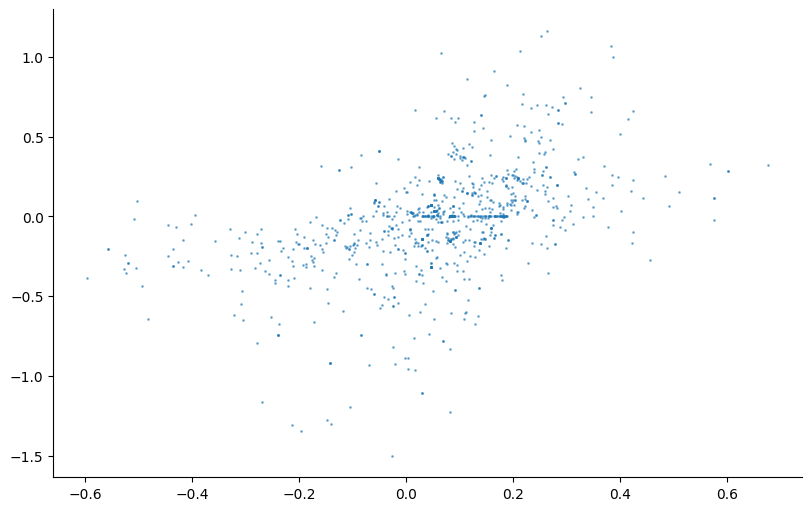

In [10]:
scit.pl.int.scatter(
    [np.c_[
        gs[1] - gs[0],
        late_entropy - early_entropy
    ]], s=1, alpha=0.5
)

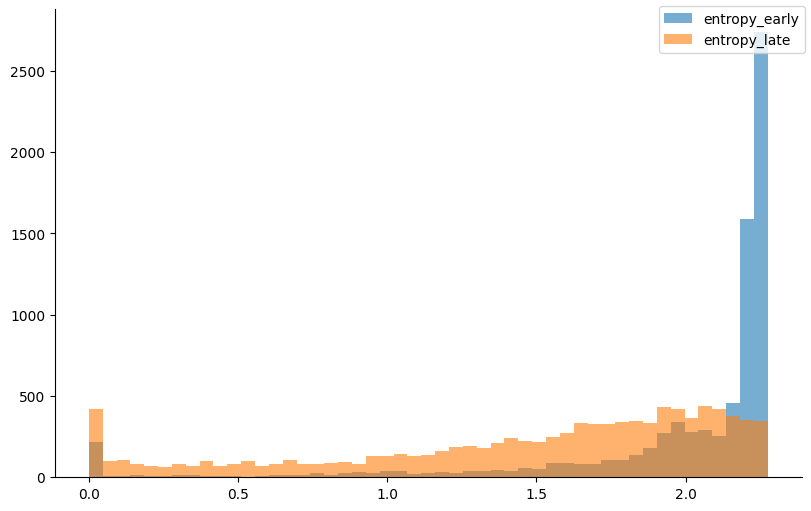

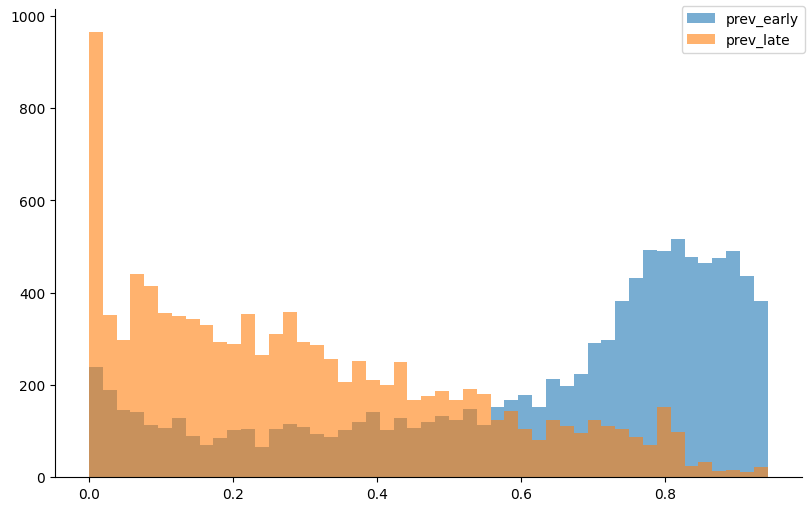

In [508]:
b = ['entropy_early', 'entropy_late']
scit.pl.int.histogram([df[i] for i in b], b)
b = ['prev_early', 'prev_late']
scit.pl.int.histogram([df[i] for i in b], b)

In [510]:
_df.filter(pl.col('a')==1)['name'].to_numpy()

array(['CG6013', 'CG8043', 'lncRNA:CR45911', ..., 'toy', 'Rad23', 'Slip1'],
      dtype=object)

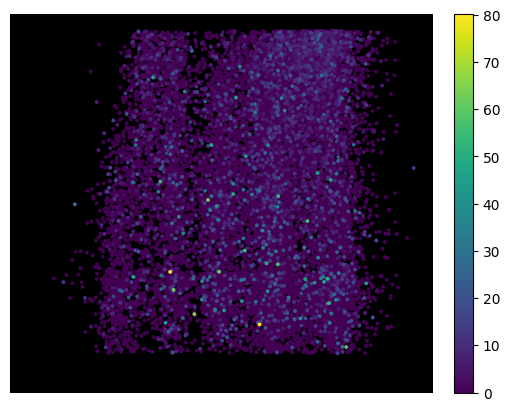

In [36]:
# Visualize marker:
marker_name = 'SCAP'

scit.tl.layer_pick_features(cttag, lc_acet, marker_name)
scit.tl.copy_to_obs(cttag, lc_acet, binarize=False)
scit.pl.embedding2d(cttag, 'X_landscape', 'copied_data', black_background=True)


In [44]:
gs = list(acet_marker['group'].unique())
rs = []
ls = []
for g in gs:
    markers = acet_marker.filter(pl.col('pval')<0.05).filter(pl.col('group')==g).top_k(200,by='pval',reverse=True)['name'].to_numpy()
    scit.tl.layer_pick_features(cttag, lc_acet, markers)
    df_acet = scit.adv.shannon_entropy(cttag, lc_acet, 'timep', 'label')
    rs.append(df_acet)
    ls.append(g)

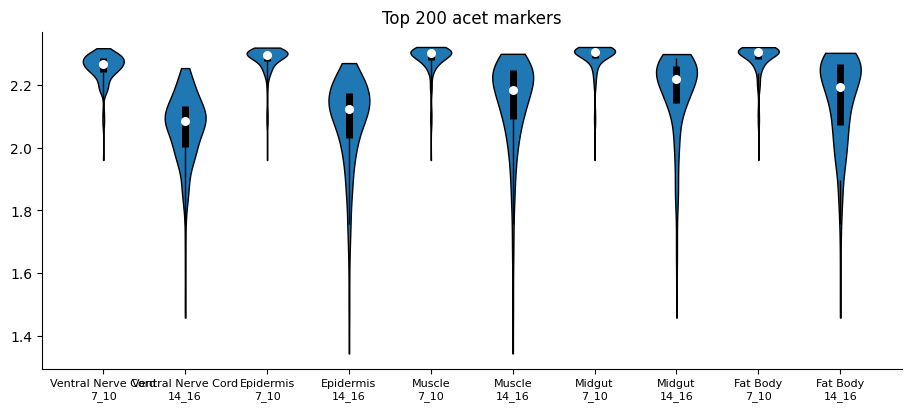

In [45]:
scit.set_defaults(figsize=(9,4))
res = [[r['entropy_8_10h'].to_numpy(), r['entropy_14_16h'].to_numpy()] for r in rs]
les = [[l+'\n7_10', l+'\n14_16'] for l in ls]

scit.pl.int.violin([item for row in res for item in row], labels=[item for row in les for item in row], label_size=8, color='tab:blue', title="Top 200 acet markers", show=False).savefig('private/newest/figures/acet_entropy_change.pdf')

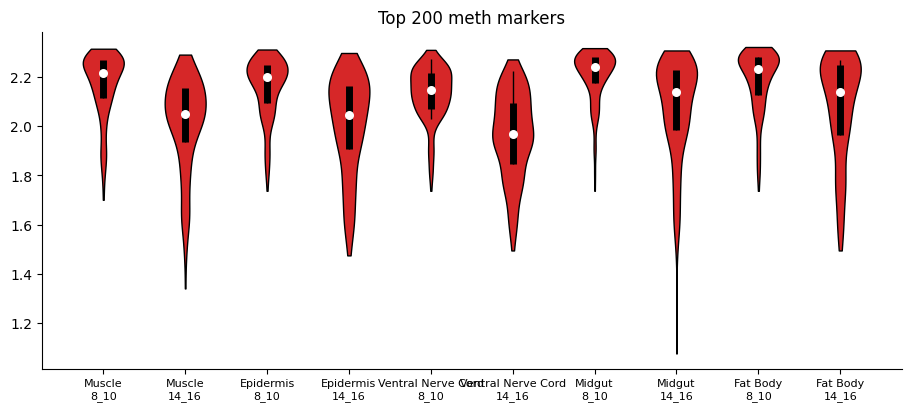

In [43]:
scit.set_defaults(figsize=(9,4))
res = [[r['entropy_8_10h'].to_numpy(), r['entropy_14_16h'].to_numpy()] for r in rs]
les = [[l+'\n8_10', l+'\n14_16'] for l in ls]

scit.pl.int.violin([item for row in res for item in row], labels=[item for row in les for item in row], title="Top 200 meth markers", label_size=8, color='tab:red', show=False).savefig('private/newest/figures/meth_entropy_change.pdf')

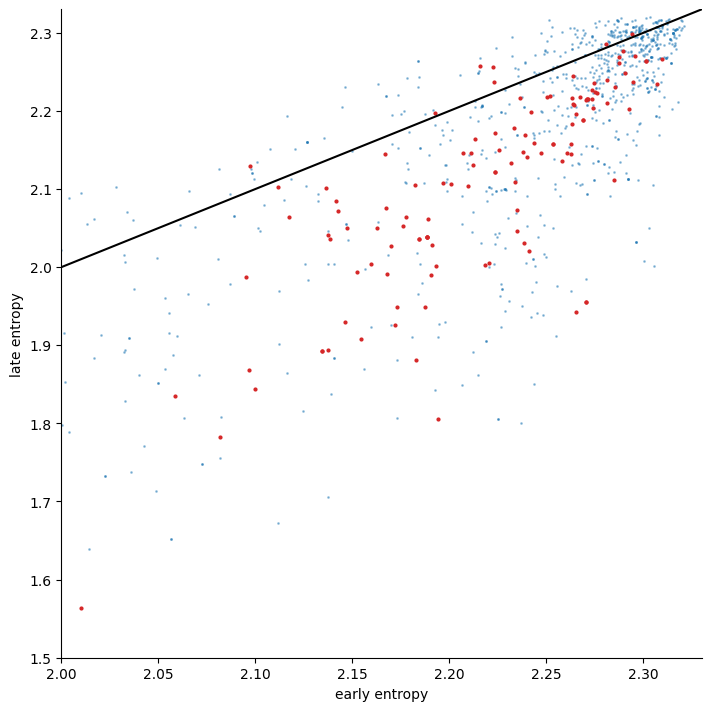

In [16]:
from scipy.stats import entropy
scit.set_defaults(figsize=(7,7))
early_entropy = entropy(ds[0], axis=0, base=2)
late_entropy = entropy(ds[1], axis=0, base=2)
from src.plotting._helper import MplWrap

gn = m.top_markers[0][1]['name'].to_numpy()
ids = np.array([scit.tl.get_gene_index(cttag.uns['gene_names_acet'][activemask], _gn, error_on_not_found=False) for _gn in gn])
ids = ids[ids != -1]
plw =MplWrap(True)
plw.ax.scatter(early_entropy, late_entropy, s = 1, alpha=0.4)
plw.ax.scatter(early_entropy[ids], late_entropy[ids], s = 4, color='tab:red')
plw.ax.set_ylabel('late entropy')
plw.ax.set_xlabel('early entropy')
plw.ax.set_ylim(1.5,2.33)
plw.ax.set_xlim(2,2.33)
plw.ax.axline([0,0], [2.3,2.3], c='black')
plw.despine()

In [53]:
scit.set_defaults(figsize=(10,3))
scit.pl.int.histogram(early_entropy - late_entropy)

NameError: name 'early_entropy' is not defined

In [9]:
from scipy.stats import entropy
scit.set_defaults(figsize=(8,5))
early_entropy = entropy(ds[0], axis=0, base=2)
late_entropy = entropy(ds[1], axis=0, base=2)

echng = early_entropy - late_entropy
echngs = []
for I in range(5):
    gn = m.top_markers[I][1]['name'].to_numpy()
    ids = np.array([scit.tl.get_gene_index(cttag.uns['gene_names_acet'][activemask], _gn, error_on_not_found=False) for _gn in gn])
    ids = ids[ids != -1]
    echngs.append((m.top_markers[I][0], echng[ids]))

scit.pl.int.violin([echng, *[e[1] for e in echngs]], ['all', *[e[0] for e in echngs]],show=False).savefig('private/newest/figures/entropy_markers_meth.pdf')

NameError: name 'm' is not defined

In [ ]:
scit.set_defaults(figsize=(10,3))
scit.pl.int.histogram(early_entropy - late_entropy)

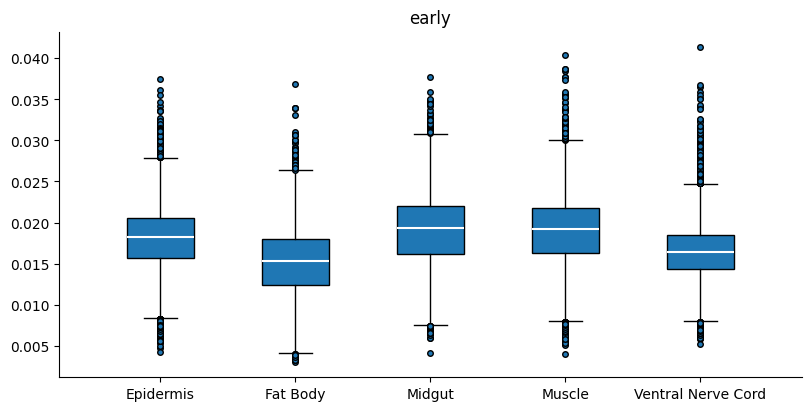

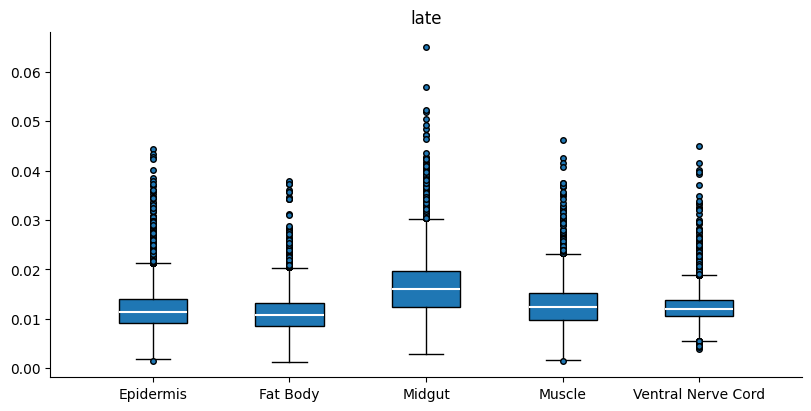

In [ ]:
lc_acet = scit.tl.make_layer_config(
    "acet",
    in_obsm=True,
    #log_transform=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
lc_meth = scit.tl.make_layer_config(
    "meth",
    in_obsm=True,
    #log_transform=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)